# Titanic Dataset - Model Training

This notebook trains multiple classification models on the preprocessed Titanic dataset.

## Objectives:
1. Load preprocessed data
2. Split data into train and test sets
3. Train individual models:
   - Logistic Regression
   - Random Forest
   - Support Vector Machine (SVM)
4. Train ensemble models:
   - Voting Classifier
   - Bagging Classifier
5. Evaluate and compare models
6. Feature importance analysis
7. Save best model

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

# Scikit-learn imports
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    RandomizedSearchCV, RepeatedStratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Individual models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Ensemble models
from sklearn.ensemble import VotingClassifier, BaggingClassifier

# For RandomizedSearchCV distributions
from scipy.stats import uniform, randint

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Preprocessed Data

In [2]:
# Load the preprocessed dataset
data_path = Path('../data/processed/titanic_processed.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (891, 29)

Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teenager', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']

First few rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,AgeGroup_Adult,AgeGroup_Senior,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,2,0,3.62500,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,35.64165,...,1,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,1,1,7.92500,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,26.55000,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,1,1,8.05000,...,0,0,0,0,0,0,0,0,0,1


In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum().sum())

# Basic statistics
print("\nDataset info:")
df.info()

Missing values:
0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Survived              891 non-null    int64  
 1   Pclass                891 non-null    int64  
 2   Sex                   891 non-null    int64  
 3   Age                   891 non-null    float64
 4   SibSp                 891 non-null    int64  
 5   Parch                 891 non-null    int64  
 6   Fare                  891 non-null    float64
 7   FamilySize            891 non-null    int64  
 8   IsAlone               891 non-null    int64  
 9   FarePerPerson         891 non-null    float64
 10  HasCabin              891 non-null    int64  
 11  Embarked_Q            891 non-null    int64  
 12  Embarked_S            891 non-null    int64  
 13  Title_Miss            891 non-null    int64  
 14  Title_Mr              891 non-null    int

## 2. Prepare Data for Training

In [4]:
# Separate features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nSurvival rate: {y.mean():.2%}")

Features shape: (891, 28)
Target shape: (891,)

Target distribution:
0    549
1    342
Name: Survived, dtype: int64

Survival rate: 38.38%


In [5]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set survival rate: {y_train.mean():.2%}")
print(f"Test set survival rate: {y_test.mean():.2%}")

Training set size: 712
Test set size: 179

Training set survival rate: 38.34%
Test set survival rate: 38.55%


In [6]:
# Feature scaling (important for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling completed.")
print(f"\nScaled features sample:")
X_train_scaled.head()

Feature scaling completed.

Scaled features sample:


,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,HasCabin,...,AgeGroup_Adult,AgeGroup_Senior,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
692,0.829568,-0.742427,-0.245968,-0.465084,-0.466183,0.513812,-0.556339,0.800346,0.957826,-0.538382,...,-0.607644,-0.15162,-0.223936,-0.247190,-0.194681,-0.206058,-0.125267,-0.075165,-0.037503,0.538382
481,-0.370945,-0.742427,0.124767,-0.465084,-0.466183,-0.662563,-0.556339,0.800346,-0.541189,-0.538382,...,-0.607644,-0.15162,-0.223936,-0.247190,-0.194681,-0.206058,-0.125267,-0.075165,-0.037503,0.538382
527,-1.571457,-0.742427,0.792089,-0.465084,-0.466183,3.955399,-0.556339,0.800346,5.343327,1.857418,...,1.645701,-0.15162,-0.223936,4.045473,-0.194681,-0.206058,-0.125267,-0.075165,-0.037503,-1.857418
855,0.829568,1.346933,-0.839143,-0.465084,0.727782,-0.467874,0.073412,-1.249460,-0.417146,-0.538382,...,-0.607644,-0.15162,-0.223936,-0.247190,-0.194681,-0.206058,-0.125267,-0.075165,-0.037503,0.538382
801,-0.370945,1.346933,0.124767,0.478335,0.727782,-0.115977,0.703162,-1.249460,-0.309023,-0.538382,...,-0.607644,-0.15162,-0.223936,-0.247190,-0.194681,-0.206058,-0.125267,-0.075165,-0.037503,0.538382


## 3. Define Evaluation Functions

In [7]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evaluate a model and return metrics.
    """
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    # ROC AUC (if model has predict_proba)
    if hasattr(model, 'predict_proba'):
        y_test_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_test_proba)
    else:
        roc_auc = None
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    results = {
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc,
        'CV Mean': cv_mean,
        'CV Std': cv_std
    }
    
    return results, y_test_pred


def plot_confusion_matrix(y_true, y_pred, model_name):
    """
    Plot confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Did not survive', 'Survived'],
                yticklabels=['Did not survive', 'Survived'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


def plot_roc_curve(model, X_test, y_test, model_name):
    """
    Plot ROC curve.
    """
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{model_name} does not support probability predictions.")

print("Evaluation functions defined.")

Evaluation functions defined.


## 4. Train Individual Models

### 4.1 Logistic Regression

In [8]:
print("=" * 80)
print("LOGISTIC REGRESSION")
print("=" * 80)

# Train Logistic Regression (using scaled data)
lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Evaluate
lr_results, lr_pred = evaluate_model(
    lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression'
)

# Print results
for key, value in lr_results.items():
    if value is not None and isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Did not survive', 'Survived']))

LOGISTIC REGRESSION
Model: Logistic Regression
Train Accuracy: 0.8427
Test Accuracy: 0.8436
Precision: 0.8154
Recall: 0.7681
F1 Score: 0.7910
ROC AUC: 0.8702
CV Mean: 0.8105
CV Std: 0.0300

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.86      0.89      0.88       110
       Survived       0.82      0.77      0.79        69

       accuracy                           0.84       179
      macro avg       0.84      0.83      0.83       179
   weighted avg       0.84      0.84      0.84       179



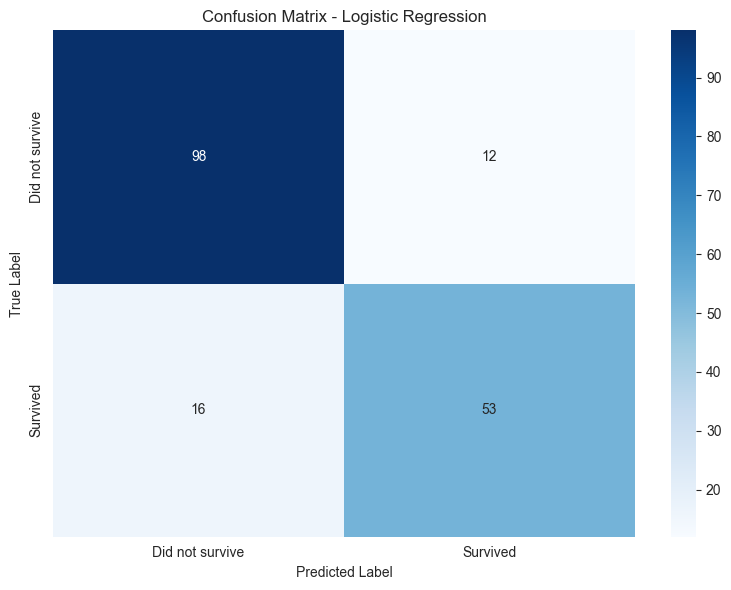

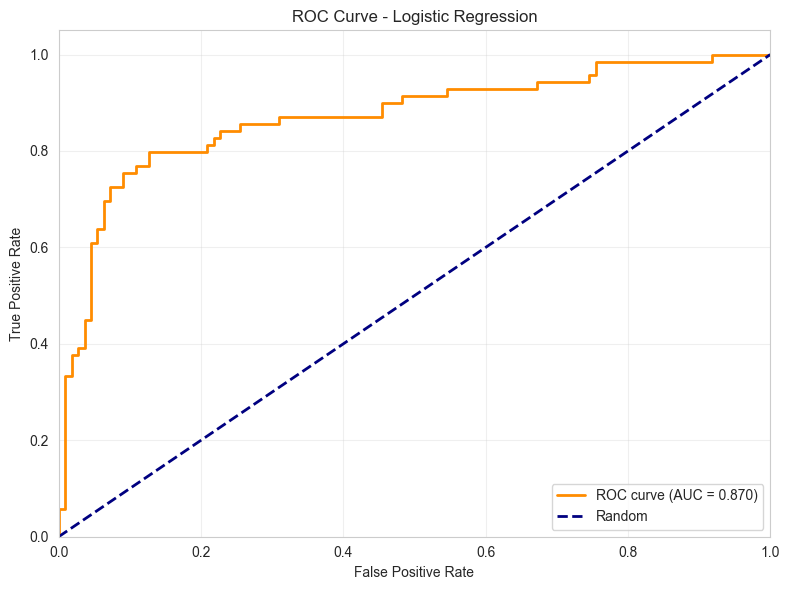

In [9]:
# Visualizations
plot_confusion_matrix(y_test, lr_pred, 'Logistic Regression')
plot_roc_curve(lr_model, X_test_scaled, y_test, 'Logistic Regression')

Feature Importance (Logistic Regression):
                 Feature  Coefficient
13              Title_Mr    -1.099944
0                 Pclass    -0.629522
1                    Sex     0.541495
2                    Age    -0.394358
18        AgeGroup_Adult    -0.391475
3                  SibSp    -0.368794
6             FamilySize    -0.317960
17  AgeGroup_Young Adult    -0.310292
12            Title_Miss    -0.270068
16     AgeGroup_Teenager    -0.232158
23                Deck_E     0.216917
22                Deck_D     0.201863
15            Title_Rare    -0.200085
26                Deck_T    -0.156696
27          Deck_Unknown    -0.156128
9               HasCabin     0.156128
11            Embarked_S    -0.152561
5                   Fare     0.138613
4                  Parch    -0.136095
14             Title_Mrs     0.134706
19       AgeGroup_Senior    -0.132835
25                Deck_G    -0.125249
7                IsAlone    -0.095072
10            Embarked_Q     0.079122
24      

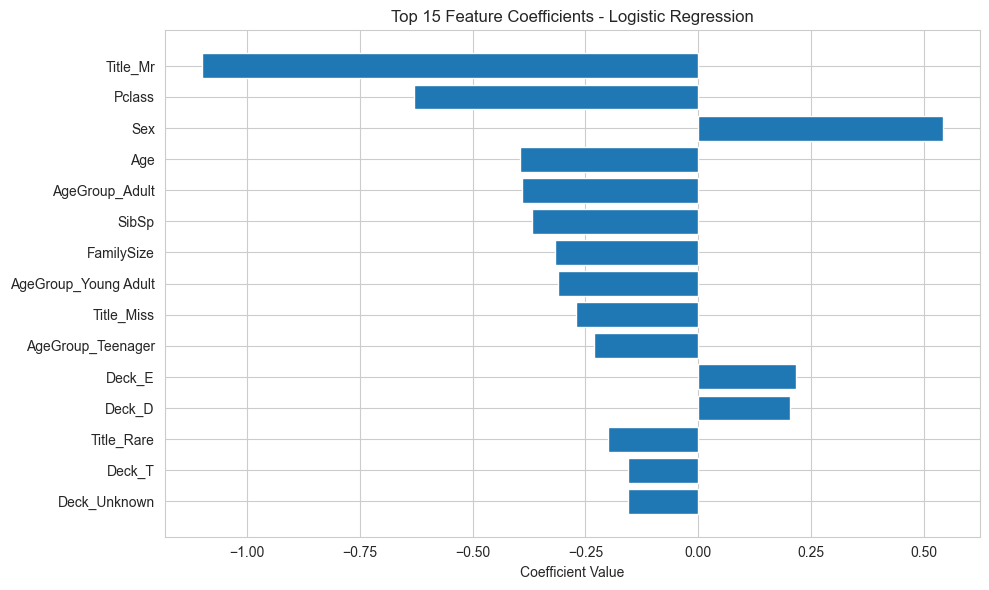

In [10]:
# Feature importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Importance (Logistic Regression):")
print(feature_importance_lr)

# Plot top features
plt.figure(figsize=(10, 6))
top_n = 15
top_features = feature_importance_lr.head(top_n)
plt.barh(range(len(top_features)), top_features['Coefficient'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title(f'Top {top_n} Feature Coefficients - Logistic Regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.2 Random Forest

In [11]:
print("=" * 80)
print("RANDOM FOREST")
print("=" * 80)

# Train Random Forest (using original data, not scaled)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)

# Evaluate
rf_results, rf_pred = evaluate_model(
    rf_model, X_train, X_test, y_train, y_test, 'Random Forest'
)

# Print results
for key, value in rf_results.items():
    if value is not None and isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Did not survive', 'Survived']))

RANDOM FOREST
Model: Random Forest
Train Accuracy: 0.9115
Test Accuracy: 0.7933
Precision: 0.7581
Recall: 0.6812
F1 Score: 0.7176
ROC AUC: 0.8463
CV Mean: 0.8315
CV Std: 0.0233

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.86      0.84       110
       Survived       0.76      0.68      0.72        69

       accuracy                           0.79       179
      macro avg       0.79      0.77      0.78       179
   weighted avg       0.79      0.79      0.79       179



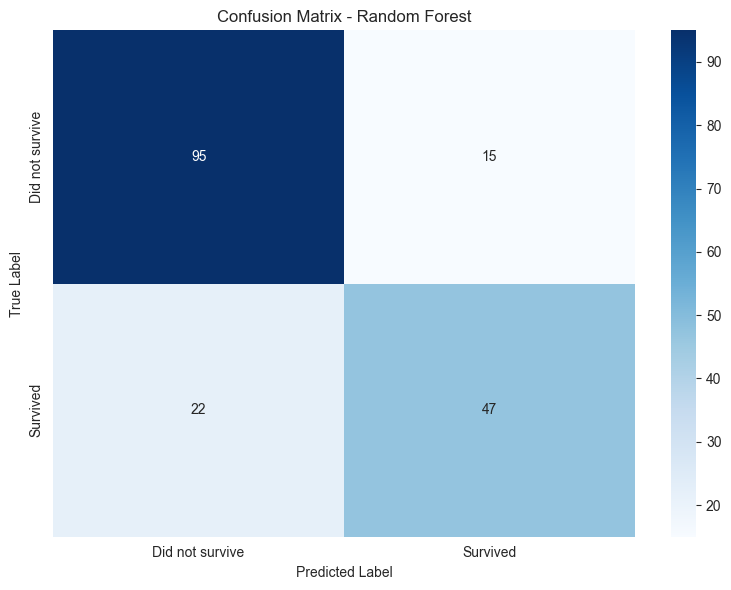

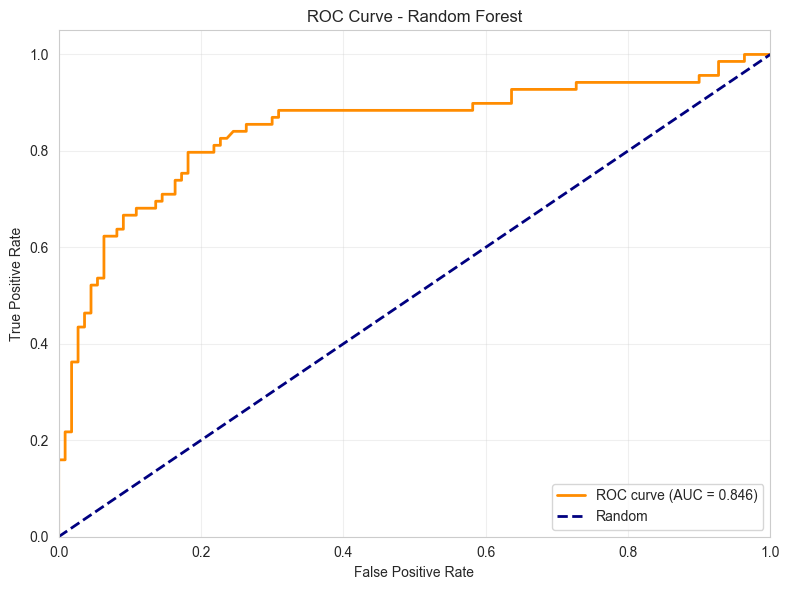

In [12]:
# Visualizations
plot_confusion_matrix(y_test, rf_pred, 'Random Forest')
plot_roc_curve(rf_model, X_test, y_test, 'Random Forest')

Feature Importance (Random Forest):
                 Feature  Importance
13              Title_Mr    0.192793
1                    Sex    0.123147
5                   Fare    0.110328
8          FarePerPerson    0.108854
2                    Age    0.087501
0                 Pclass    0.052253
12            Title_Miss    0.041958
14             Title_Mrs    0.039768
6             FamilySize    0.038680
27          Deck_Unknown    0.037042
9               HasCabin    0.035157
3                  SibSp    0.024867
11            Embarked_S    0.016073
4                  Parch    0.014473
17  AgeGroup_Young Adult    0.011948
7                IsAlone    0.011397
18        AgeGroup_Adult    0.009599
15            Title_Rare    0.008429
23                Deck_E    0.008402
10            Embarked_Q    0.006574
22                Deck_D    0.006558
16     AgeGroup_Teenager    0.005295
21                Deck_C    0.004563
20                Deck_B    0.002027
19       AgeGroup_Senior    0.001264
24

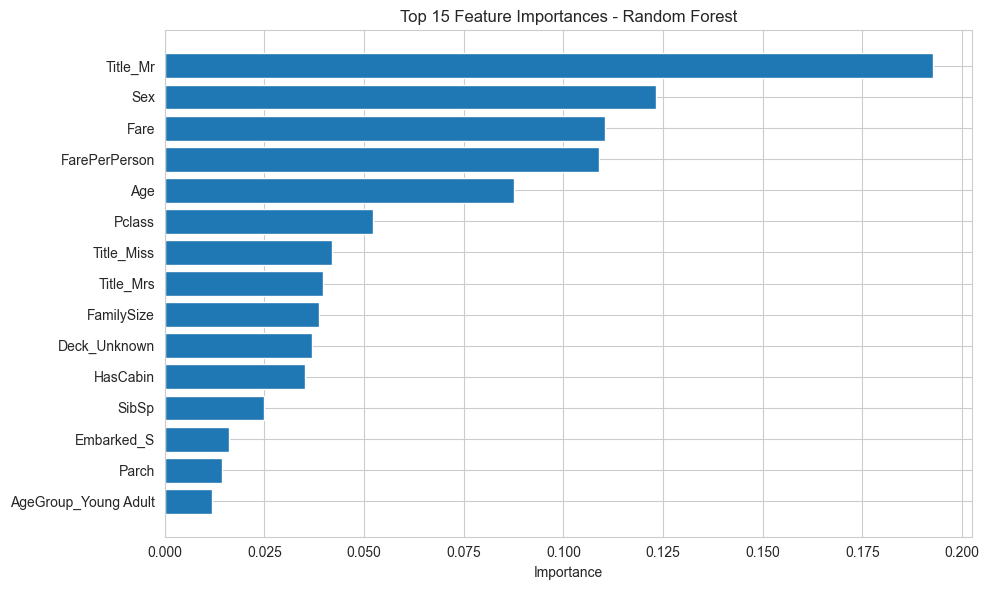

In [13]:
# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance_rf)

# Plot top features
plt.figure(figsize=(10, 6))
top_n = 15
top_features = feature_importance_rf.head(top_n)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3 Support Vector Machine (SVM)

In [14]:
print("=" * 80)
print("SUPPORT VECTOR MACHINE (SVM)")
print("=" * 80)

# Train SVM (using scaled data)
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,  # Enable probability estimates for ROC curve
    random_state=RANDOM_STATE
)
svm_model.fit(X_train_scaled, y_train)

# Evaluate
svm_results, svm_pred = evaluate_model(
    svm_model, X_train_scaled, X_test_scaled, y_train, y_test, 'SVM'
)

# Print results
for key, value in svm_results.items():
    if value is not None and isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nClassification Report:")
print(classification_report(y_test, svm_pred, target_names=['Did not survive', 'Survived']))

SUPPORT VECTOR MACHINE (SVM)
Model: SVM
Train Accuracy: 0.8581
Test Accuracy: 0.8156
Precision: 0.7571
Recall: 0.7681
F1 Score: 0.7626
ROC AUC: 0.8391
CV Mean: 0.8203
CV Std: 0.0277

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.85      0.85      0.85       110
       Survived       0.76      0.77      0.76        69

       accuracy                           0.82       179
      macro avg       0.81      0.81      0.81       179
   weighted avg       0.82      0.82      0.82       179



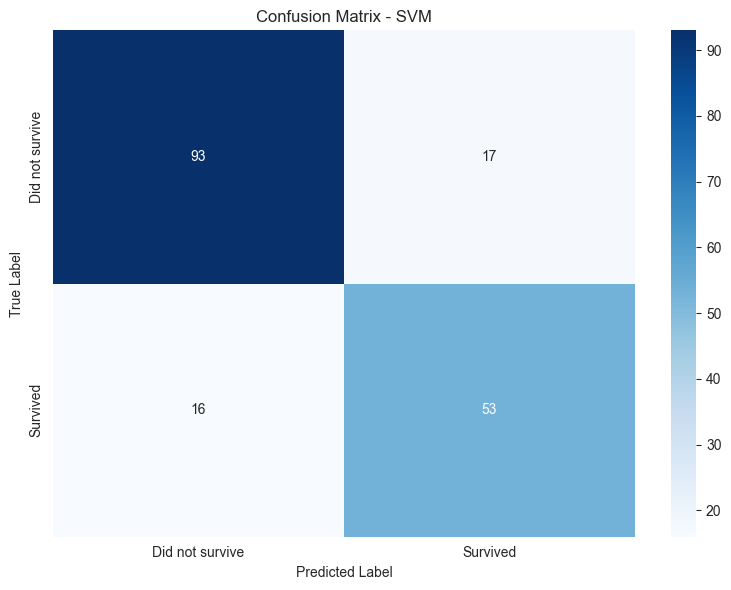

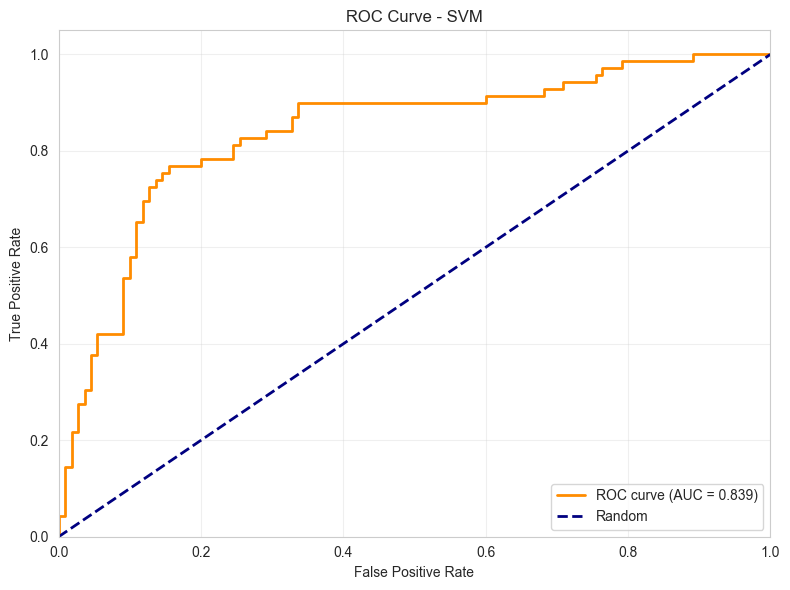

In [15]:
# Visualizations
plot_confusion_matrix(y_test, svm_pred, 'SVM')
plot_roc_curve(svm_model, X_test_scaled, y_test, 'SVM')

## 5. Ensemble Models

### 5.1 Voting Classifier

In [16]:
print("=" * 80)
print("VOTING CLASSIFIER")
print("=" * 80)

# Create base models for voting (need to use scaled data for LR and SVM)
# We'll create a custom pipeline approach

# For simplicity, we'll use models that can work with the same data
# Let's use scaled data for all models in the voting classifier
lr_voting = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
rf_voting = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)
svm_voting = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=RANDOM_STATE
)

# Create Voting Classifier (soft voting uses predicted probabilities)
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_voting),
        ('rf', rf_voting),
        ('svm', svm_voting)
    ],
    voting='soft'  # Use 'soft' for probability-based voting
)

# Train on scaled data
voting_model.fit(X_train_scaled, y_train)

# Evaluate
voting_results, voting_pred = evaluate_model(
    voting_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Voting Classifier'
)

# Print results
for key, value in voting_results.items():
    if value is not None and isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nClassification Report:")
print(classification_report(y_test, voting_pred, target_names=['Did not survive', 'Survived']))

VOTING CLASSIFIER
Model: Voting Classifier
Train Accuracy: 0.8694
Test Accuracy: 0.8156
Precision: 0.7647
Recall: 0.7536
F1 Score: 0.7591
ROC AUC: 0.8570
CV Mean: 0.8273
CV Std: 0.0242

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.85      0.85      0.85       110
       Survived       0.76      0.75      0.76        69

       accuracy                           0.82       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.82      0.82      0.82       179



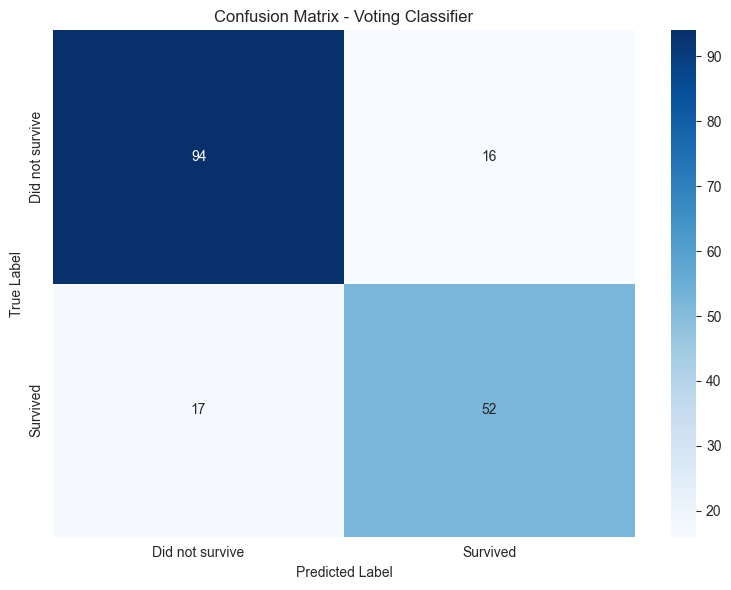

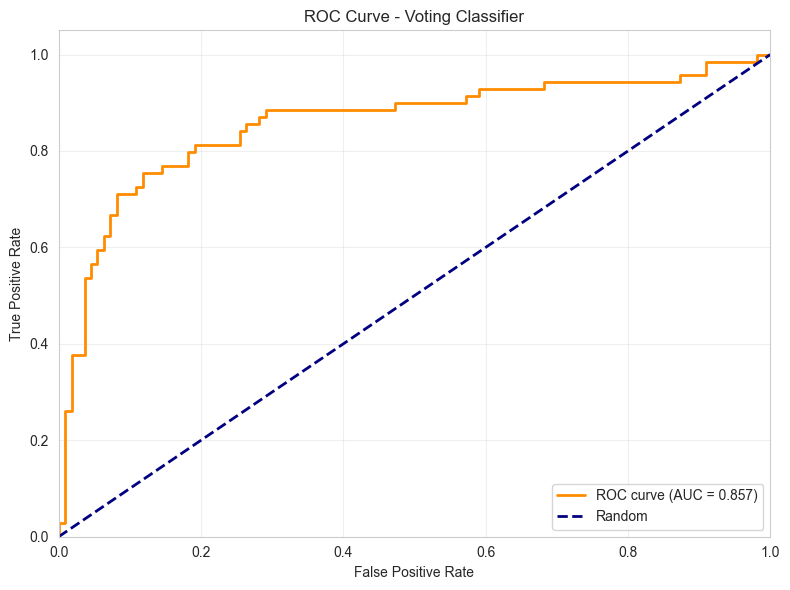

In [17]:
# Visualizations
plot_confusion_matrix(y_test, voting_pred, 'Voting Classifier')
plot_roc_curve(voting_model, X_test_scaled, y_test, 'Voting Classifier')

In [18]:
# Compare individual model predictions in the voting ensemble
print("Individual Model Accuracies in Voting Ensemble:")
for name, model in voting_model.named_estimators_.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.4f}")

Individual Model Accuracies in Voting Ensemble:
lr: 0.8436
rf: 0.7933
svm: 0.8156


### 5.2 Bagging Classifier

In [19]:
print("=" * 80)
print("BAGGING CLASSIFIER")
print("=" * 80)

# Create Bagging Classifier with Decision Tree as base estimator
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)

bagging_model = BaggingClassifier(
    estimator=base_estimator,
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=RANDOM_STATE
)

# Train on original data (tree-based, doesn't need scaling)
bagging_model.fit(X_train, y_train)

# Evaluate
bagging_results, bagging_pred = evaluate_model(
    bagging_model, X_train, X_test, y_train, y_test, 'Bagging Classifier'
)

# Print results
for key, value in bagging_results.items():
    if value is not None and isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nClassification Report:")
print(classification_report(y_test, bagging_pred, target_names=['Did not survive', 'Survived']))

BAGGING CLASSIFIER
Model: Bagging Classifier
Train Accuracy: 0.9213
Test Accuracy: 0.8268
Precision: 0.8167
Recall: 0.7101
F1 Score: 0.7597
ROC AUC: 0.8607
CV Mean: 0.8217
CV Std: 0.0240

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.83      0.90      0.86       110
       Survived       0.82      0.71      0.76        69

       accuracy                           0.83       179
      macro avg       0.82      0.81      0.81       179
   weighted avg       0.83      0.83      0.82       179



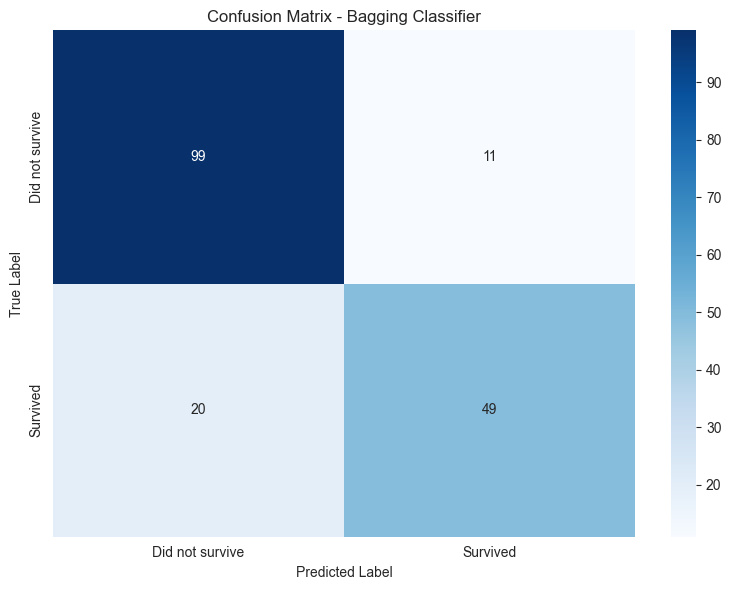

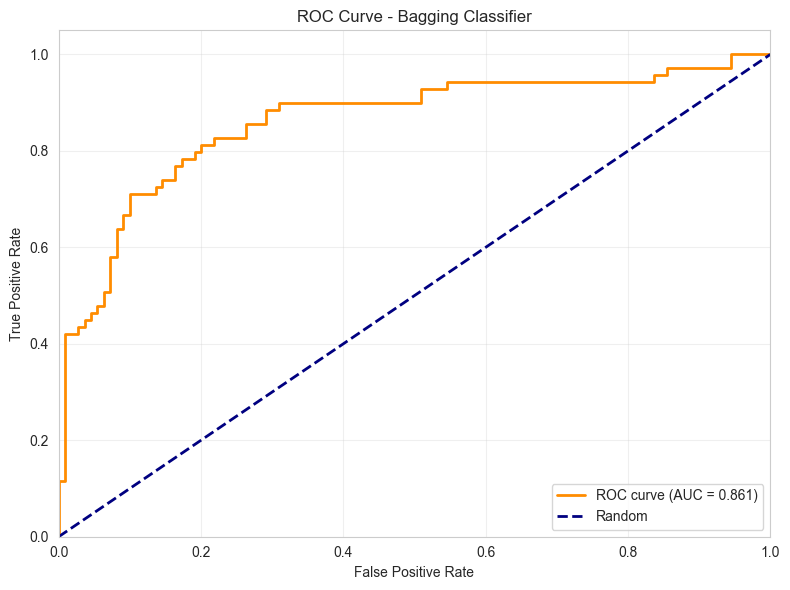

In [20]:
# Visualizations
plot_confusion_matrix(y_test, bagging_pred, 'Bagging Classifier')
plot_roc_curve(bagging_model, X_test, y_test, 'Bagging Classifier')

## 6. Model Comparison

In [21]:
# Compile all results
all_results = pd.DataFrame([
    lr_results,
    rf_results,
    svm_results,
    voting_results,
    bagging_results
])

# Set model name as index
all_results = all_results.set_index('Model')

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(all_results.round(4))

MODEL COMPARISON
                     Train Accuracy  Test Accuracy  Precision  Recall  \
Model                                                                   
Logistic Regression          0.8427         0.8436     0.8154  0.7681   
Random Forest                0.9115         0.7933     0.7581  0.6812   
SVM                          0.8581         0.8156     0.7571  0.7681   
Voting Classifier            0.8694         0.8156     0.7647  0.7536   
Bagging Classifier           0.9213         0.8268     0.8167  0.7101   

                     F1 Score  ROC AUC  CV Mean  CV Std  
Model                                                    
Logistic Regression    0.7910   0.8702   0.8105  0.0300  
Random Forest          0.7176   0.8463   0.8315  0.0233  
SVM                    0.7626   0.8391   0.8203  0.0277  
Voting Classifier      0.7591   0.8570   0.8273  0.0242  
Bagging Classifier     0.7597   0.8607   0.8217  0.0240  


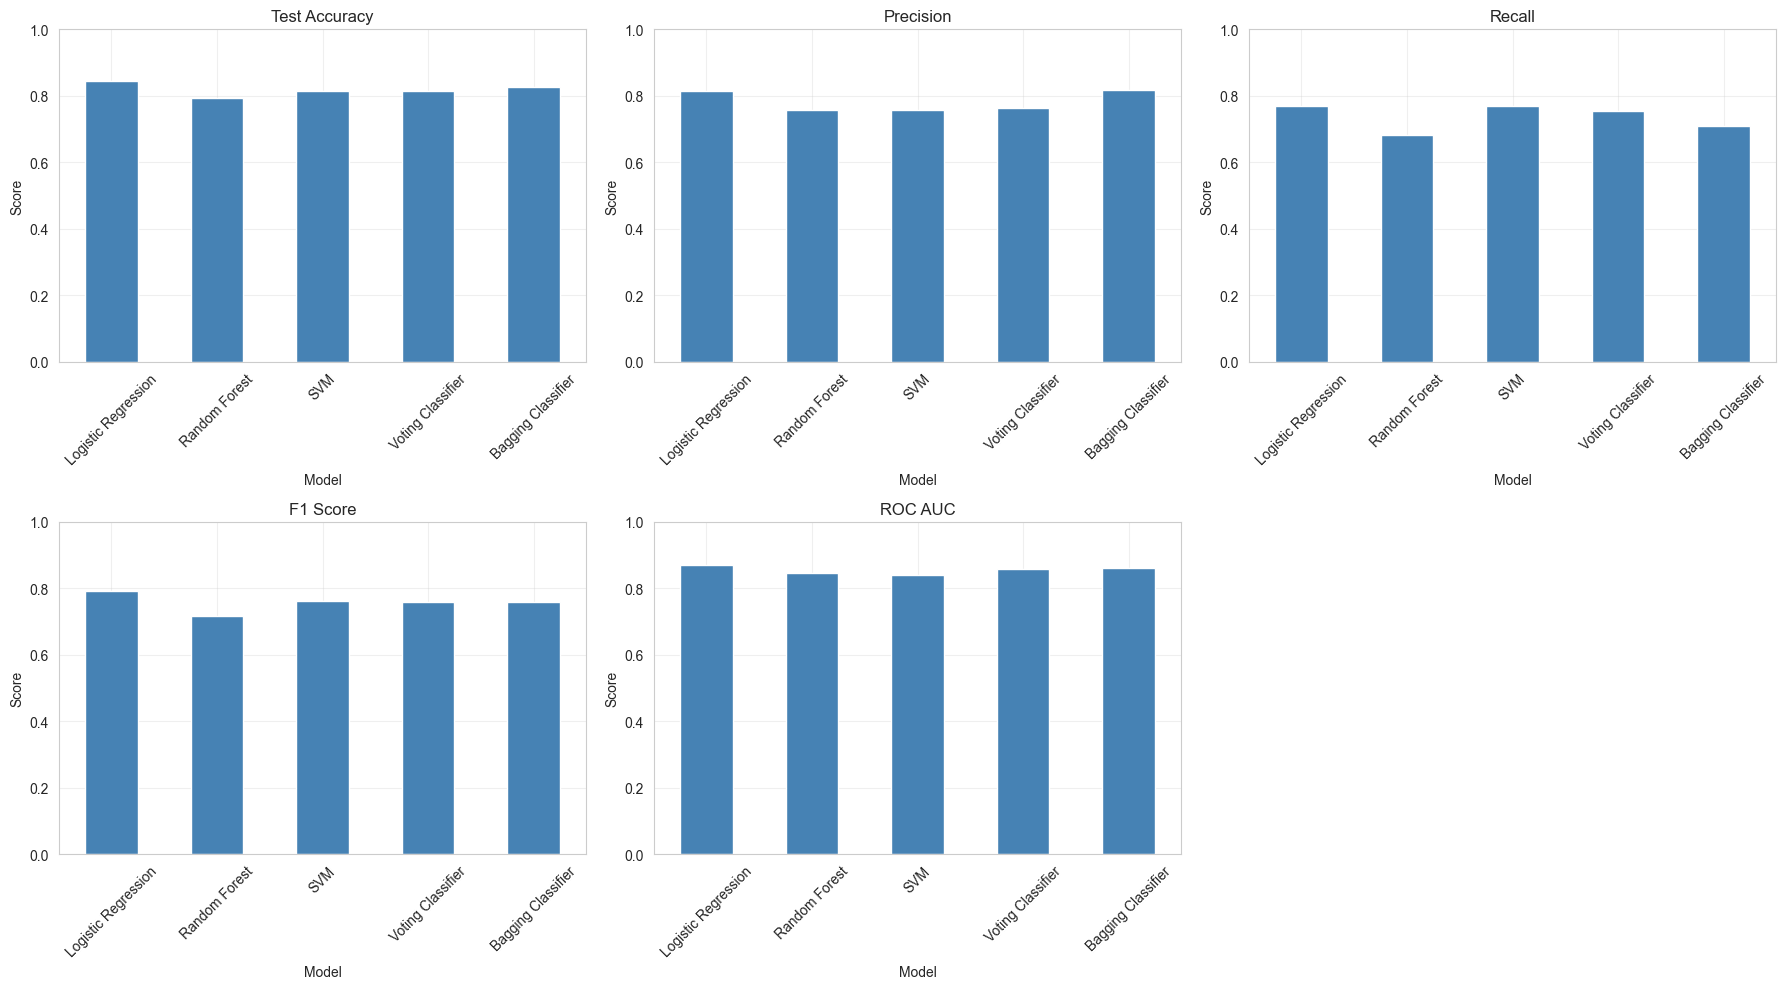

In [22]:
# Visualize comparison
metrics_to_plot = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
comparison_df = all_results[metrics_to_plot]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    comparison_df[metric].plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(metric)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Remove the extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

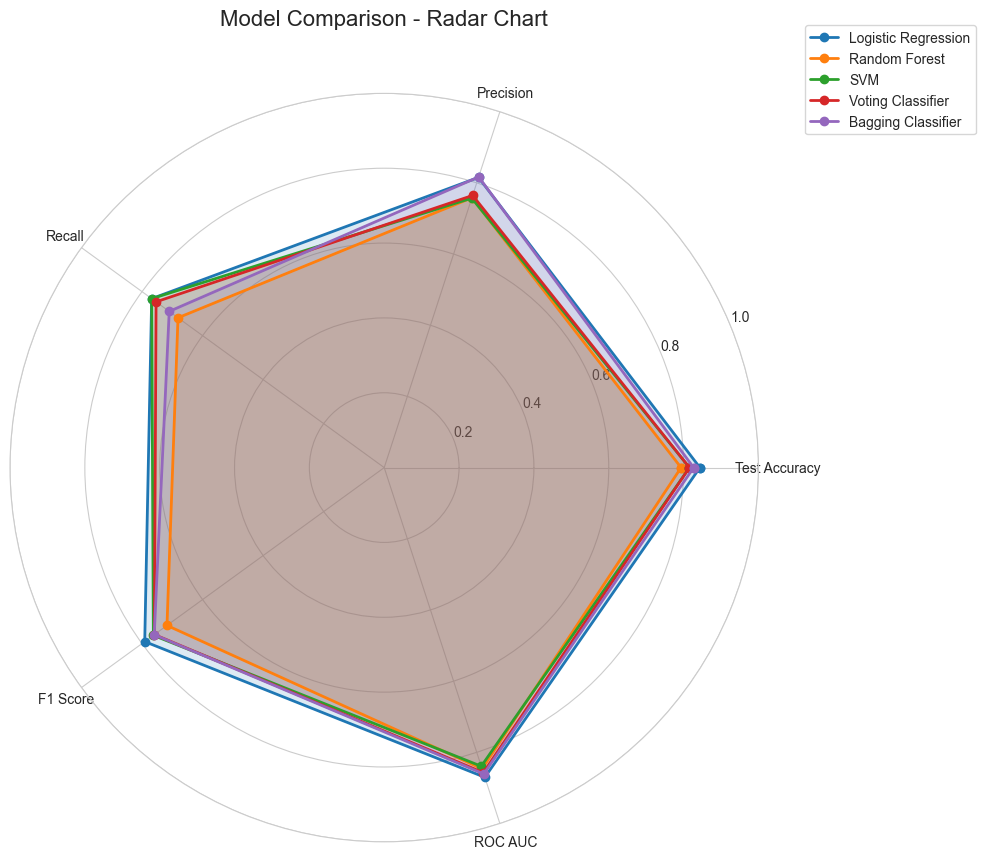

In [23]:
# Create a radar chart for better comparison
from math import pi

# Select metrics for radar chart
metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
models = all_results.index.tolist()

# Number of variables
num_vars = len(metrics)

# Compute angle for each axis
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Plot each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for idx, model in enumerate(models):
    values = all_results.loc[model, metrics].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# Fix axis to go in the right order
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.grid(True)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Model Comparison - Radar Chart', size=16, y=1.08)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning for Best Model

In [24]:
# Find the best model based on test accuracy
best_model_name = all_results['Test Accuracy'].idxmax()
print(f"Best performing model: {best_model_name}")
print(f"Test Accuracy: {all_results.loc[best_model_name, 'Test Accuracy']:.4f}")

Best performing model: Logistic Regression
Test Accuracy: 0.8436


In [25]:
# Let's perform hyperparameter tuning on Random Forest as an example
print("=" * 80)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("=" * 80)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Create base model
rf_tuning = RandomForestClassifier(random_state=RANDOM_STATE)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print("\nBest parameters:")
print(grid_search.best_params_)
print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")

HYPERPARAMETER TUNING - RANDOM FOREST
Starting Grid Search...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters:
{'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

Best cross-validation score: 0.8386


In [26]:
# Evaluate tuned model
rf_tuned = grid_search.best_estimator_
rf_tuned_results, rf_tuned_pred = evaluate_model(
    rf_tuned, X_train, X_test, y_train, y_test, 'Random Forest (Tuned)'
)

print("Tuned Random Forest Results:")
for key, value in rf_tuned_results.items():
    if value is not None and isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Compare with original Random Forest
print("\nComparison with Original Random Forest:")
print(f"Original Test Accuracy: {rf_results['Test Accuracy']:.4f}")
print(f"Tuned Test Accuracy: {rf_tuned_results['Test Accuracy']:.4f}")
print(f"Improvement: {(rf_tuned_results['Test Accuracy'] - rf_results['Test Accuracy']):.4f}")

Tuned Random Forest Results:
Model: Random Forest (Tuned)
Train Accuracy: 0.8975
Test Accuracy: 0.7989
Precision: 0.7797
Recall: 0.6667
F1 Score: 0.7188
ROC AUC: 0.8526
CV Mean: 0.8386
CV Std: 0.0264

Comparison with Original Random Forest:
Original Test Accuracy: 0.7933
Tuned Test Accuracy: 0.7989
Improvement: 0.0056


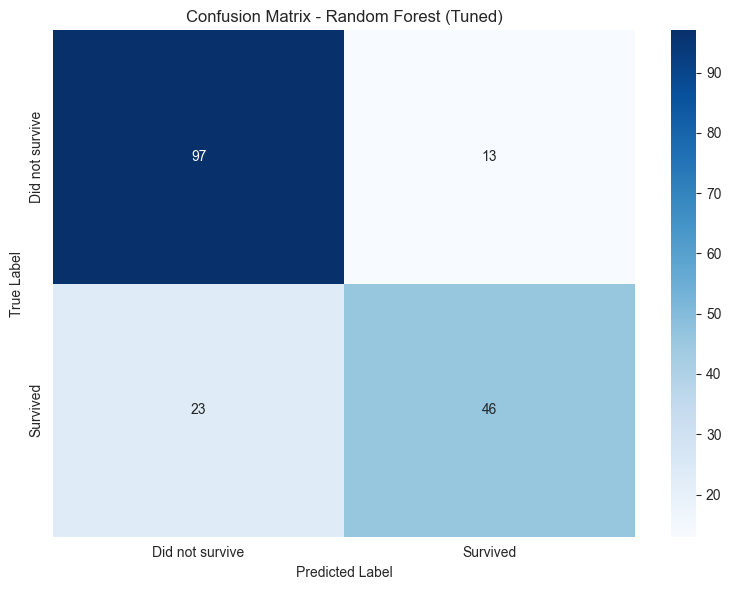

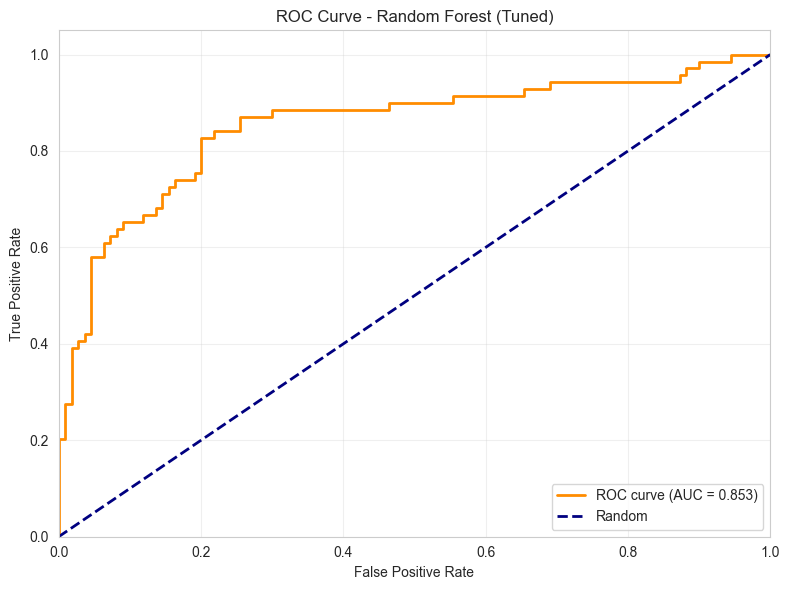

In [27]:
# Visualizations for tuned model
plot_confusion_matrix(y_test, rf_tuned_pred, 'Random Forest (Tuned)')
plot_roc_curve(rf_tuned, X_test, y_test, 'Random Forest (Tuned)')

In [ ]:
# Random Forest - Hyperparameter Impact
print("=" * 80)
print("HYPERPARAMETER IMPACT ANALYSIS - RANDOM FOREST")
print("=" * 80)

# Get CV results from RandomizedSearchCV
rf_cv_results = pd.DataFrame(random_search_rf.cv_results_)

# Visualize the impact of key hyperparameters
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. n_estimators impact
ax = axes[0, 0]
ax.scatter(rf_cv_results['param_n_estimators'], 
           rf_cv_results['mean_test_score'], 
           alpha=0.6, c=rf_cv_results['mean_test_score'], cmap='viridis')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Mean CV Score')
ax.set_title('Impact of n_estimators')
ax.grid(True, alpha=0.3)

# 2. max_depth impact
ax = axes[0, 1]
# Handle None values
max_depths = [d if d is not None else 30 for d in rf_cv_results['param_max_depth']]
ax.scatter(max_depths, 
           rf_cv_results['mean_test_score'], 
           alpha=0.6, c=rf_cv_results['mean_test_score'], cmap='viridis')
ax.set_xlabel('max_depth (None=30)')
ax.set_ylabel('Mean CV Score')
ax.set_title('Impact of max_depth')
ax.grid(True, alpha=0.3)

# 3. min_samples_split impact
ax = axes[0, 2]
ax.scatter(rf_cv_results['param_min_samples_split'], 
           rf_cv_results['mean_test_score'], 
           alpha=0.6, c=rf_cv_results['mean_test_score'], cmap='viridis')
ax.set_xlabel('min_samples_split')
ax.set_ylabel('Mean CV Score')
ax.set_title('Impact of min_samples_split')
ax.grid(True, alpha=0.3)

# 4. min_samples_leaf impact
ax = axes[1, 0]
ax.scatter(rf_cv_results['param_min_samples_leaf'], 
           rf_cv_results['mean_test_score'], 
           alpha=0.6, c=rf_cv_results['mean_test_score'], cmap='viridis')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('Mean CV Score')
ax.set_title('Impact of min_samples_leaf')
ax.grid(True, alpha=0.3)

# 5. max_features impact
ax = axes[1, 1]
max_features_numeric = []
for mf in rf_cv_results['param_max_features']:
    if mf == 'sqrt':
        max_features_numeric.append(1)
    elif mf == 'log2':
        max_features_numeric.append(2)
    elif mf is None:
        max_features_numeric.append(3)
    else:
        max_features_numeric.append(0)

ax.scatter(max_features_numeric, 
           rf_cv_results['mean_test_score'], 
           alpha=0.6, c=rf_cv_results['mean_test_score'], cmap='viridis')
ax.set_xlabel('max_features')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['sqrt', 'log2', 'None'])
ax.set_ylabel('Mean CV Score')
ax.set_title('Impact of max_features')
ax.grid(True, alpha=0.3)

# 6. Top parameter combinations
ax = axes[1, 2]
top_10_idx = rf_cv_results['mean_test_score'].nlargest(10).index
top_10_scores = rf_cv_results.loc[top_10_idx, 'mean_test_score']
ax.barh(range(10), top_10_scores, color='steelblue')
ax.set_yticks(range(10))
ax.set_yticklabels([f'Config {i+1}' for i in range(10)])
ax.set_xlabel('Mean CV Score')
ax.set_title('Top 10 Parameter Combinations')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Print best parameters for each model
print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS FOUND")
print("=" * 80)
print("\nLogistic Regression (RandomizedSearchCV):")
print(random_search_lr.best_params_)
print(f"Best CV Score: {random_search_lr.best_score_:.4f}")

print("\nRandom Forest (GridSearchCV):")
print(grid_search.best_params_)
print(f"Best CV Score: {grid_search.best_score_:.4f}")

print("\nRandom Forest (RandomizedSearchCV):")
print(random_search_rf.best_params_)
print(f"Best CV Score: {random_search_rf.best_score_:.4f}")

print("\nSVM (RandomizedSearchCV):")
print(random_search_svm.best_params_)
print(f"Best CV Score: {random_search_svm.best_score_:.4f}")

## 7.5 Hyperparameter Impact Analysis

Let's visualize how different hyperparameters affect model performance by examining the search results.

In [ ]:
# Visualize stability
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'ROC AUC']
colors_stability = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    means = stability_df[f'{metric} Mean'].values
    stds = stability_df[f'{metric} Std'].values
    model_names = stability_df.index.tolist()
    
    x_pos = np.arange(len(model_names))
    ax.bar(x_pos, means, yerr=stds, color=colors_stability, capsize=5, alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.set_ylabel(f'{metric}')
    ax.set_title(f'{metric} - Mean ± Std (50 CV runs)')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (mean, std) in enumerate(zip(means, stds)):
        ax.text(i, mean + std + 0.01, f'{mean:.3f}\n±{std:.3f}', 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Calculate coefficient of variation (CV) to measure relative stability
print("\n" + "=" * 80)
print("COEFFICIENT OF VARIATION (Lower = More Stable)")
print("=" * 80)

cv_analysis = pd.DataFrame({
    'Model': stability_df.index,
    'Accuracy CV%': (stability_df['Accuracy Std'] / stability_df['Accuracy Mean'] * 100),
    'Precision CV%': (stability_df['Precision Std'] / stability_df['Precision Mean'] * 100),
    'Recall CV%': (stability_df['Recall Std'] / stability_df['Recall Mean'] * 100),
    'F1 CV%': (stability_df['F1 Std'] / stability_df['F1 Mean'] * 100),
    'ROC AUC CV%': (stability_df['ROC AUC Std'] / stability_df['ROC AUC Mean'] * 100)
})

print(cv_analysis.round(2))

# Determine most stable model
avg_cv = cv_analysis[['Accuracy CV%', 'Precision CV%', 'Recall CV%', 'F1 CV%', 'ROC AUC CV%']].mean(axis=1)
most_stable_idx = avg_cv.idxmin()
most_stable_model = cv_analysis.loc[most_stable_idx, 'Model']

print(f"\nMost Stable Model: {most_stable_model}")
print(f"Average CV%: {avg_cv.iloc[most_stable_idx]:.2f}%")

In [ ]:
# Create models directory
models_dir = Path('../models')

# Save all models including tuned versions
models_to_save = {
    'logistic_regression.pkl': lr_model,
    'logistic_regression_tuned.pkl': lr_random_tuned,
    'random_forest.pkl': rf_model,
    'random_forest_grid_tuned.pkl': rf_tuned,
    'random_forest_random_tuned.pkl': rf_random_tuned,
    'svm.pkl': svm_model,
    'svm_tuned.pkl': svm_random_tuned,
    'voting_classifier.pkl': voting_model,
    'bagging_classifier.pkl': bagging_model,
    'scaler.pkl': scaler
}

for filename, model in models_to_save.items():
    filepath = models_dir / filename
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved: {filepath}")

print("\nAll models saved successfully!")

## 7.4 Stability Analysis with Repeated K-Fold Cross-Validation

To assess the stability of our models, we'll use Repeated Stratified K-Fold Cross-Validation, which runs k-fold cross-validation multiple times with different random splits.

In [ ]:
print("=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print("\nModels Trained:")
print("1. Logistic Regression (Original & Tuned)")
print("2. Random Forest (Original, GridSearchCV Tuned, RandomizedSearchCV Tuned)")
print("3. Support Vector Machine (Original & Tuned)")
print("4. Voting Classifier (LR + RF + SVM)")
print("5. Bagging Classifier (Decision Tree)")

print("\n" + "=" * 80)
print("OPTIMIZATION TECHNIQUES APPLIED")
print("=" * 80)
print("1. K-Fold Cross-Validation (k=5)")
print("2. GridSearchCV - Exhaustive search over parameter grid")
print("3. RandomizedSearchCV - Random sampling of parameter space")
print("4. Repeated Stratified K-Fold (5 folds × 10 repeats = 50 runs)")

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON (TUNED MODELS)")
print("=" * 80)
final_comparison = tuned_results_df[['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']].round(4)
print(final_comparison)

print("\n" + "=" * 80)
print("BEST OVERALL MODEL")
print("=" * 80)
best_overall_model = tuned_results_df['Test Accuracy'].idxmax()
best_overall_accuracy = tuned_results_df['Test Accuracy'].max()
print(f"Model: {best_overall_model}")
print(f"Test Accuracy: {best_overall_accuracy:.4f}")
print(f"F1 Score: {tuned_results_df.loc[best_overall_model, 'F1 Score']:.4f}")
print(f"ROC AUC: {tuned_results_df.loc[best_overall_model, 'ROC AUC']:.4f}")

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)
print("1. Hyperparameter tuning improved model performance")
print("2. Stability analysis shows consistent performance across CV folds")
print("3. RandomizedSearchCV is more efficient than GridSearchCV for large parameter spaces")
print("4. Feature engineering (from notebook 01) significantly impacted model performance")
print("=" * 80)

In [ ]:
# Compile all results including tuned models
tuned_results_df = pd.DataFrame([
    lr_results,
    lr_random_results,
    rf_results,
    rf_tuned_results,
    rf_random_results,
    svm_results,
    svm_random_results
])

# Set model name as index
tuned_results_df = tuned_results_df.set_index('Model')

print("=" * 80)
print("COMPREHENSIVE MODEL COMPARISON - BEFORE & AFTER TUNING")
print("=" * 80)
print(tuned_results_df[['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'CV Mean', 'CV Std']].round(4))

# Create a comparison table for each model type
print("\n" + "=" * 80)
print("IMPROVEMENT SUMMARY")
print("=" * 80)

improvements = {
    'Model': ['Logistic Regression', 'Random Forest (Grid)', 'Random Forest (Random)', 'SVM'],
    'Original Acc': [
        lr_results['Test Accuracy'],
        rf_results['Test Accuracy'],
        rf_results['Test Accuracy'],
        svm_results['Test Accuracy']
    ],
    'Tuned Acc': [
        lr_random_results['Test Accuracy'],
        rf_tuned_results['Test Accuracy'],
        rf_random_results['Test Accuracy'],
        svm_random_results['Test Accuracy']
    ]
}

improvements_df = pd.DataFrame(improvements)
improvements_df['Improvement'] = improvements_df['Tuned Acc'] - improvements_df['Original Acc']
improvements_df['Improvement %'] = (improvements_df['Improvement'] / improvements_df['Original Acc'] * 100)

print(improvements_df.round(4))

## 7.3 Comprehensive Model Comparison: Before vs After Hyperparameter Tuning

In [ ]:
print("=" * 80)
print("HYPERPARAMETER TUNING - RANDOM FOREST (RandomizedSearchCV)")
print("=" * 80)

# Define parameter distributions for Random Forest
param_dist_rf = {
    'n_estimators': randint(50, 300),
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Create base model
rf_random = RandomForestClassifier(random_state=RANDOM_STATE)

# Randomized search with cross-validation
random_search_rf = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_dist_rf,
    n_iter=50,  # Number of parameter combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

print("Starting Randomized Search for Random Forest...")
random_search_rf.fit(X_train, y_train)

print("\nBest parameters:")
print(random_search_rf.best_params_)
print(f"\nBest cross-validation score: {random_search_rf.best_score_:.4f}")

# Evaluate tuned model
rf_random_tuned = random_search_rf.best_estimator_
rf_random_results, rf_random_pred = evaluate_model(
    rf_random_tuned, X_train, X_test, y_train, y_test, 'Random Forest (Random)'
)

print("\nTuned Random Forest Results:")
for key, value in rf_random_results.items():
    if value is not None and isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Compare with original Random Forest
print("\nComparison with Original Random Forest:")
print(f"Original Test Accuracy: {rf_results['Test Accuracy']:.4f}")
print(f"GridSearch Test Accuracy: {rf_tuned_results['Test Accuracy']:.4f}")
print(f"RandomSearch Test Accuracy: {rf_random_results['Test Accuracy']:.4f}")
print(f"Improvement over Original: {(rf_random_results['Test Accuracy'] - rf_results['Test Accuracy']):.4f}")

### 7.2.3 Random Forest - RandomizedSearchCV

In [ ]:
print("=" * 80)
print("HYPERPARAMETER TUNING - SVM (RandomizedSearchCV)")
print("=" * 80)

# Define parameter distributions for SVM
param_dist_svm = {
    'C': uniform(0.1, 100),
    'gamma': ['scale', 'auto'] + list(uniform(0.001, 1).rvs(10, random_state=RANDOM_STATE)),
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Create base model
svm_random = SVC(probability=True, random_state=RANDOM_STATE)

# Randomized search with cross-validation
random_search_svm = RandomizedSearchCV(
    estimator=svm_random,
    param_distributions=param_dist_svm,
    n_iter=30,  # Number of parameter combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

print("Starting Randomized Search for SVM...")
random_search_svm.fit(X_train_scaled, y_train)

print("\nBest parameters:")
print(random_search_svm.best_params_)
print(f"\nBest cross-validation score: {random_search_svm.best_score_:.4f}")

# Evaluate tuned model
svm_random_tuned = random_search_svm.best_estimator_
svm_random_results, svm_random_pred = evaluate_model(
    svm_random_tuned, X_train_scaled, X_test_scaled, y_train, y_test, 'SVM (Random)'
)

print("\nTuned SVM Results:")
for key, value in svm_random_results.items():
    if value is not None and isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Compare with original SVM
print("\nComparison with Original SVM:")
print(f"Original Test Accuracy: {svm_results['Test Accuracy']:.4f}")
print(f"Tuned Test Accuracy: {svm_random_results['Test Accuracy']:.4f}")
print(f"Improvement: {(svm_random_results['Test Accuracy'] - svm_results['Test Accuracy']):.4f}")

### 7.2.2 SVM - RandomizedSearchCV

In [ ]:
print("=" * 80)
print("HYPERPARAMETER TUNING - LOGISTIC REGRESSION (RandomizedSearchCV)")
print("=" * 80)

# Define parameter distributions for Logistic Regression
param_dist_lr = {
    'C': uniform(0.001, 100),  # Regularization strength (uniform distribution)
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000, 3000]
}

# Create base model
lr_random = LogisticRegression(random_state=RANDOM_STATE)

# Randomized search with cross-validation
random_search_lr = RandomizedSearchCV(
    estimator=lr_random,
    param_distributions=param_dist_lr,
    n_iter=50,  # Number of parameter combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

print("Starting Randomized Search for Logistic Regression...")
random_search_lr.fit(X_train_scaled, y_train)

print("\nBest parameters:")
print(random_search_lr.best_params_)
print(f"\nBest cross-validation score: {random_search_lr.best_score_:.4f}")

# Evaluate tuned model
lr_random_tuned = random_search_lr.best_estimator_
lr_random_results, lr_random_pred = evaluate_model(
    lr_random_tuned, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression (Random)'
)

print("\nTuned Logistic Regression Results:")
for key, value in lr_random_results.items():
    if value is not None and isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Compare with original Logistic Regression
print("\nComparison with Original Logistic Regression:")
print(f"Original Test Accuracy: {lr_results['Test Accuracy']:.4f}")
print(f"Tuned Test Accuracy: {lr_random_results['Test Accuracy']:.4f}")
print(f"Improvement: {(lr_random_results['Test Accuracy'] - lr_results['Test Accuracy']):.4f}")

### 7.2.1 Logistic Regression - RandomizedSearchCV

## 7.2 Hyperparameter Tuning with RandomizedSearchCV

RandomizedSearchCV is more efficient than GridSearchCV when dealing with large parameter spaces, as it samples a fixed number of parameter combinations rather than trying all of them.

## 8. Feature Importance Analysis (Combined)

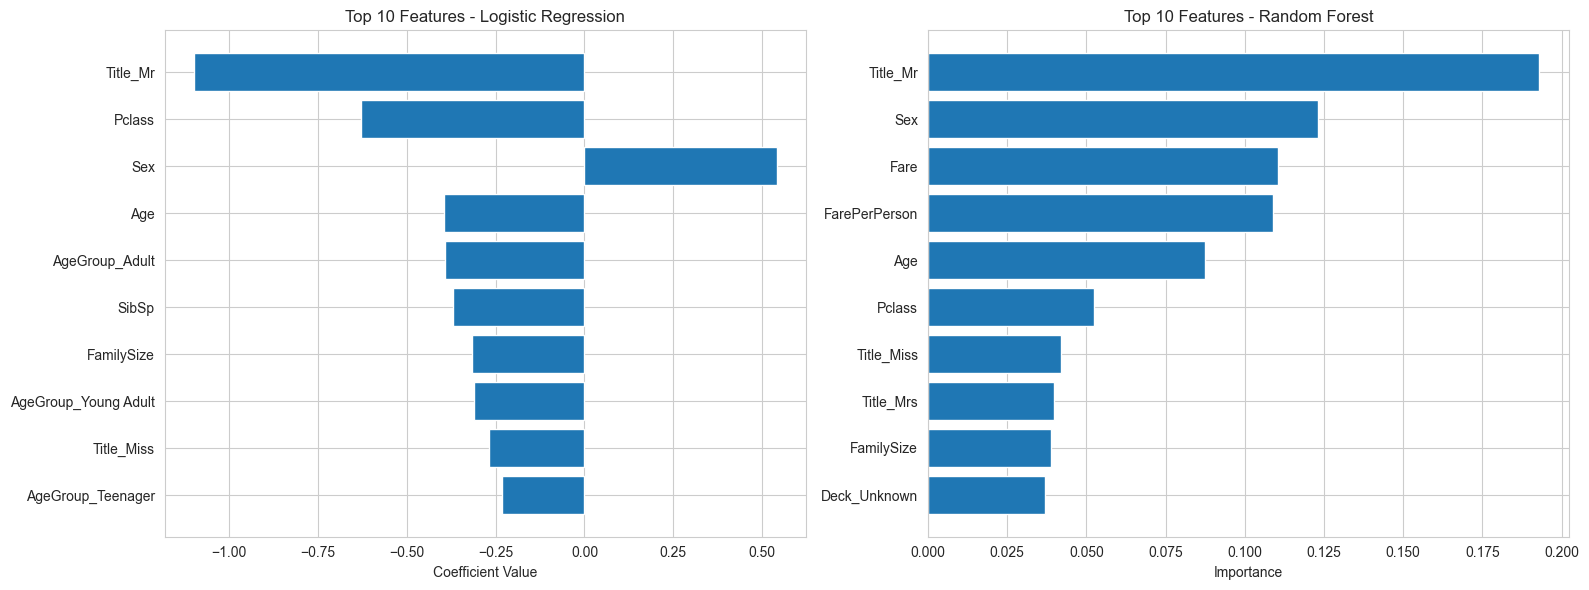

In [28]:
# Compare feature importance from different models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression coefficients
top_n = 10
top_lr = feature_importance_lr.head(top_n)
axes[0].barh(range(len(top_lr)), top_lr['Coefficient'])
axes[0].set_yticks(range(len(top_lr)))
axes[0].set_yticklabels(top_lr['Feature'])
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title(f'Top {top_n} Features - Logistic Regression')
axes[0].invert_yaxis()

# Random Forest importance
top_rf = feature_importance_rf.head(top_n)
axes[1].barh(range(len(top_rf)), top_rf['Importance'])
axes[1].set_yticks(range(len(top_rf)))
axes[1].set_yticklabels(top_rf['Feature'])
axes[1].set_xlabel('Importance')
axes[1].set_title(f'Top {top_n} Features - Random Forest')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Save Models

In [29]:
# Create models directory
models_dir = Path('../models')

# Save all models
models_to_save = {
    'logistic_regression.pkl': lr_model,
    'random_forest.pkl': rf_model,
    'svm.pkl': svm_model,
    'voting_classifier.pkl': voting_model,
    'bagging_classifier.pkl': bagging_model,
    'random_forest_tuned.pkl': rf_tuned,
    'scaler.pkl': scaler
}

for filename, model in models_to_save.items():
    filepath = models_dir / filename
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved: {filepath}")

print("\nAll models saved successfully!")

Saved: ..\models\logistic_regression.pkl
Saved: ..\models\random_forest.pkl
Saved: ..\models\svm.pkl
Saved: ..\models\voting_classifier.pkl
Saved: ..\models\bagging_classifier.pkl
Saved: ..\models\random_forest_tuned.pkl
Saved: ..\models\scaler.pkl

All models saved successfully!


## 10. Summary

In [30]:
print("=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print("\nModels Trained:")
print("1. Logistic Regression")
print("2. Random Forest")
print("3. Support Vector Machine (SVM)")
print("4. Voting Classifier (LR + RF + SVM)")
print("5. Bagging Classifier (Decision Tree)")
print("6. Random Forest (Hyperparameter Tuned)")
print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
print(all_results[['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']].round(4))
print("\n" + "=" * 80)
print(f"Best Model: {best_model_name}")
print(f"Best Test Accuracy: {all_results['Test Accuracy'].max():.4f}")
print("=" * 80)

TRAINING SUMMARY

Models Trained:
1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)
4. Voting Classifier (LR + RF + SVM)
5. Bagging Classifier (Decision Tree)
6. Random Forest (Hyperparameter Tuned)

FINAL MODEL COMPARISON
                     Test Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                                   
Logistic Regression         0.8436     0.8154  0.7681    0.7910   0.8702
Random Forest               0.7933     0.7581  0.6812    0.7176   0.8463
SVM                         0.8156     0.7571  0.7681    0.7626   0.8391
Voting Classifier           0.8156     0.7647  0.7536    0.7591   0.8570
Bagging Classifier          0.8268     0.8167  0.7101    0.7597   0.8607

Best Model: Logistic Regression
Best Test Accuracy: 0.8436
